In [150]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from langchain_ollama import ChatOllama

In [151]:
class customer_problem(TypedDict):
    problem:str
    solution:str
    department: Literal["Techical","Billing","General"]

In [152]:
identify_problem=ChatOllama(model="llama3.2:1b")
response_generator=ChatOllama(model="llama3.2:1b")

In [153]:
def problem_identifer(state:customer_problem)->customer_problem:
    problem=state["problem"]
    prompt=f"identify the department for this problem {problem} your response must be in one of Technical, Billing, or General do not explain"

    department = identify_problem.invoke(prompt).content.strip()
    valid=["Technical","Billing","General"]
    if department not in valid:
        dempartment="General"
    return {"department":department}

In [154]:
def billing_solution(state:customer_problem)->customer_problem:
    q=state["problem"]
    solution=response_generator.invoke(f"you are the biling manager for this problem {q} what is the solution for this problem"
).content

    return {"problem":q,"solution":solution}

In [155]:
def technical_solution(state:customer_problem)->customer_problem:
    q=state["problem"]
    

    solution=response_generator.invoke(f"you are the technical manager for this problem {q} what is the solution for this problem").content

    return {"problem":q,"solution":solution}

In [156]:
def general_solution(state:customer_problem)->customer_problem:
    q=state["problem"]
    solution=response_generator.invoke(f"you are the general manager for this problem {q} what is the solution for this problem").content

    return {"problem":q,"solution":solution}

In [157]:
def check_department_condition(state:customer_problem):
    return state["department"]

In [158]:
graph=StateGraph(customer_problem)

In [159]:
graph.add_node("problem_identifer",problem_identifer)
graph.add_node("billing_solution",billing_solution)
graph.add_node("technical_solution",technical_solution)
graph.add_node("general_solution",general_solution)



In [160]:
graph.add_edge(START,"problem_identifer")
graph.add_conditional_edges("problem_identifer",check_department_condition,{"Techical":"technical_solution","Billing":"billing_solution","General":"general_solution"})
graph.add_edge("billing_solution",END)
graph.add_edge("technical_solution",END)
graph.add_edge("general_solution",END)

app=graph.compile()



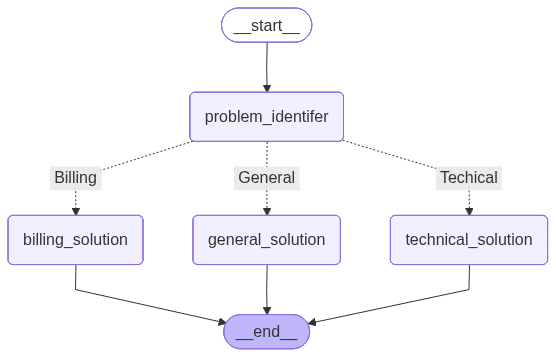

In [161]:
app

In [163]:
result=app.invoke({"problem":"my internet is not working","solution":"","department":""})
print(result)

{'problem': 'my internet is not working', 'solution': "As the bilingual manager, I'd be happy to help you troubleshoot and resolve the issue with your internet connection.\n\nTo start, can you please tell me a bit more about your internet situation? For example:\n\n* What type of internet service do you have (e.g., DSL, cable, fiber)?\n* Are you connected to the internet through a physical network cable or wirelessly?\n* Have you experienced any errors or issues with your internet connection in the past?\n* Are there any other devices on your network that might be affecting the speed or quality of your internet?\n\nThe more information you can provide, the better I'll be able to assist you and help resolve this issue.", 'department': 'Billing'}
